# Parallelizing Neural Network Training with PyTorch

In [2]:
import torch 
import numpy as np 
np.set_printoptions(precision=3)
a = [1,2,3]
b = [np.array([4,5,6])]
t_a = torch.tensor(a)
t_b = torch.tensor(b)
print(t_a)
print(t_b)

tensor([1, 2, 3])
tensor([[4, 5, 6]])


C:\Users\Aksha\AppData\Local\Temp\ipykernel_77772\2456024484.py:7: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at C:\cb\pytorch_1000000000000\work\torch\csrc\utils\tensor_new.cpp:281.)
  t_b = torch.tensor(b)


In [3]:
t_ones = torch.ones(2,3)
print(t_ones.shape)
print(t_ones)

torch.Size([2, 3])
tensor([[1., 1., 1.],
        [1., 1., 1.]])


In [4]:
rand_tensor = torch.rand(2,3)
print(rand_tensor.shape)
print(rand_tensor)

torch.Size([2, 3])
tensor([[0.5235, 0.8588, 0.6926],
        [0.6609, 0.7961, 0.7721]])


# Manipulating the data type and shape of a tensor

In [5]:
t_a_new = t_a.to(torch.int64)
print(t_a_new.dtype)

torch.int64


In [6]:
t =  torch.rand(3,5)
t_tr = torch.transpose(t,0,1)
print(t.shape, '-->' ,t_tr.shape)

torch.Size([3, 5]) --> torch.Size([5, 3])


In [7]:
t = torch.zeros(30)
t_reshape = t.reshape(5,6)
print(t_reshape)

tensor([[0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0.]])


In [8]:
t = torch.zeros(1,2,1,4,1)
t_sqz = torch.squeeze(t,2)
print(t_sqz.shape)
print(t.shape, ' --> ', t_sqz.shape)

torch.Size([1, 2, 4, 1])
torch.Size([1, 2, 1, 4, 1])  -->  torch.Size([1, 2, 4, 1])


#  Applying mathematical operations to tensor

In [9]:
torch.manual_seed(1)
t1 = 2* torch.rand(5,2) -1
t2 = torch.normal(mean = 1, std =1, size=(5,2))
t3 = torch.multiply(t1,t2)
print(t1, '\n -------------- \n', t2, '\n --------- \n', t3)


tensor([[ 0.5153, -0.4414],
        [-0.1939,  0.4694],
        [-0.9414,  0.5997],
        [-0.2057,  0.5087],
        [ 0.1390, -0.1224]]) 
 -------------- 
 tensor([[ 1.8590,  1.7056],
        [ 0.6594, -0.2720],
        [-0.1948,  1.0250],
        [ 0.2373,  2.3969],
        [ 0.6755,  1.2879]]) 
 --------- 
 tensor([[ 0.9579, -0.7528],
        [-0.1278, -0.1277],
        [ 0.1834,  0.6147],
        [-0.0488,  1.2194],
        [ 0.0939, -0.1577]])


In [10]:
t4 = torch.mean(t1,axis=0)
print(t4)

tensor([-0.1373,  0.2028])


In [11]:
t5 = torch.matmul(t1, torch.transpose(t2, 0, 1))
print(t5)

tensor([[ 0.2051,  0.4598, -0.5528, -0.9357, -0.2204],
        [ 0.4402, -0.2555,  0.5189,  1.0790,  0.4735],
        [-0.7273, -0.7839,  0.7981,  1.2141,  0.1364],
        [ 0.4853, -0.2740,  0.5616,  1.1706,  0.5162],
        [ 0.0496,  0.1250, -0.1526, -0.2605, -0.0638]])


In [12]:
t6 = torch.matmul(torch.transpose(t1, 0, 1), t2)
print(t6)

tensor([[ 1.0585, -0.3475],
        [-0.5898,  0.7960]])


In [13]:
norm_t1 = torch.linalg.norm(t1, ord=2, dim=1)
print(norm_t1)

tensor([0.6785, 0.5078, 1.1162, 0.5488, 0.1853])


## Split, stack, and concatenate tensors

In [14]:
torch.manual_seed(1)
t = torch.rand(6)
print(t)

t_splits = torch.chunk(t, 3)
[item.numpy() for item in t_splits]

tensor([0.7576, 0.2793, 0.4031, 0.7347, 0.0293, 0.7999])


[array([0.758, 0.279], dtype=float32),
 array([0.403, 0.735], dtype=float32),
 array([0.029, 0.8  ], dtype=float32)]

In [15]:
torch.manual_seed(1)
t = torch.rand(5)
print(t)
t_splits = torch.split(t, split_size_or_sections=[3, 2])
[item.numpy() for item in t_splits]


tensor([0.7576, 0.2793, 0.4031, 0.7347, 0.0293])


[array([0.758, 0.279, 0.403], dtype=float32),
 array([0.735, 0.029], dtype=float32)]

In [16]:
A = torch.ones(3,2)
B = torch.zeros(3,2)
C = torch.cat([A, B], axis=0)
print(C)

C = torch.cat([A, B], axis=1)
print(C)

tensor([[1., 1.],
        [1., 1.],
        [1., 1.],
        [0., 0.],
        [0., 0.],
        [0., 0.]])
tensor([[1., 1., 0., 0.],
        [1., 1., 0., 0.],
        [1., 1., 0., 0.]])


##  Building input pipelines in PyTorch

### Creating a Pytorch DataLoader from existing tensors

In [17]:
from torch.utils.data import DataLoader
t = torch.arange(6,dtype = torch.float32)
data_loader = DataLoader(t)
for item in data_loader:
    print(item)

tensor([0.])
tensor([1.])
tensor([2.])
tensor([3.])
tensor([4.])
tensor([5.])


In [18]:
data_loader = DataLoader(t, batch_size=3, drop_last=False)
for i, batch in enumerate(data_loader, 1):
    print(f'batch {i}:', batch)

batch 1: tensor([0., 1., 2.])
batch 2: tensor([3., 4., 5.])


### Combining two tensors into a joint dataset

In [19]:
torch.manual_seed(1)
t_x = torch.rand([4,3], dtype = torch.float32)
t_y = torch.arange(4)

In [20]:
from torch.utils.data import Dataset
class JointDataset(Dataset):
    def __init__(self, x, y):
        self.x = x
        self.y = y
       
    def __len__(self):
        return len(self.x)
        
    def __getitem__(self, idx):
        return self.x[idx], self.y[idx]

In [21]:
joint_dataset = JointDataset(t_x, t_y)
for example in joint_dataset:
    print('  x: ', example[0], '  y:  ', example[1])

  x:  tensor([0.7576, 0.2793, 0.4031])   y:   tensor(0)
  x:  tensor([0.7347, 0.0293, 0.7999])   y:   tensor(1)
  x:  tensor([0.3971, 0.7544, 0.5695])   y:   tensor(2)
  x:  tensor([0.4388, 0.6387, 0.5247])   y:   tensor(3)


In [22]:
joint_dataset = JointDataset(t_x, t_y)

### Shuffle, batch, and repeat

In [23]:
torch.manual_seed(1) 
data_loader = DataLoader(dataset=joint_dataset, batch_size=2, shuffle=True)

In [24]:
for i, batch in enumerate(data_loader, 1):
    print(f'batch {i}:', 'x:', batch[0],'\n         y:', batch[1])

batch 1: x: tensor([[0.3971, 0.7544, 0.5695],
        [0.7576, 0.2793, 0.4031]]) 
         y: tensor([2, 0])
batch 2: x: tensor([[0.7347, 0.0293, 0.7999],
        [0.4388, 0.6387, 0.5247]]) 
         y: tensor([1, 3])


In [25]:
for epoch in range(2): 
    print(f'epoch {epoch+1}')
    for i, batch in enumerate(data_loader, 1):
        print(f'batch {i}:', 'x:', batch[0], '\n  y:', batch[1])

epoch 1
batch 1: x: tensor([[0.7576, 0.2793, 0.4031],
        [0.3971, 0.7544, 0.5695]]) 
  y: tensor([0, 2])
batch 2: x: tensor([[0.7347, 0.0293, 0.7999],
        [0.4388, 0.6387, 0.5247]]) 
  y: tensor([1, 3])
epoch 2
batch 1: x: tensor([[0.4388, 0.6387, 0.5247],
        [0.3971, 0.7544, 0.5695]]) 
  y: tensor([3, 2])
batch 2: x: tensor([[0.7576, 0.2793, 0.4031],
        [0.7347, 0.0293, 0.7999]]) 
  y: tensor([0, 1])


### Creating a dataset from files on your local storage disk 

In [26]:
import pathlib
imgdir_path = pathlib.Path('cat_dog_images')
file_list = sorted([str(path) for path in imgdir_path.glob('*.jpg')])
print(file_list)

['cat_dog_images\\cat-01.jpg', 'cat_dog_images\\cat-02.jpg', 'cat_dog_images\\cat-03.jpg', 'cat_dog_images\\dog-01.jpg', 'cat_dog_images\\dog-02.jpg', 'cat_dog_images\\dog-03.jpg']


Image shape: (900, 1200, 3)
Image shape: (900, 1200, 3)
Image shape: (900, 742, 3)
Image shape: (800, 1200, 3)
Image shape: (800, 1200, 3)
Image shape: (900, 1200, 3)


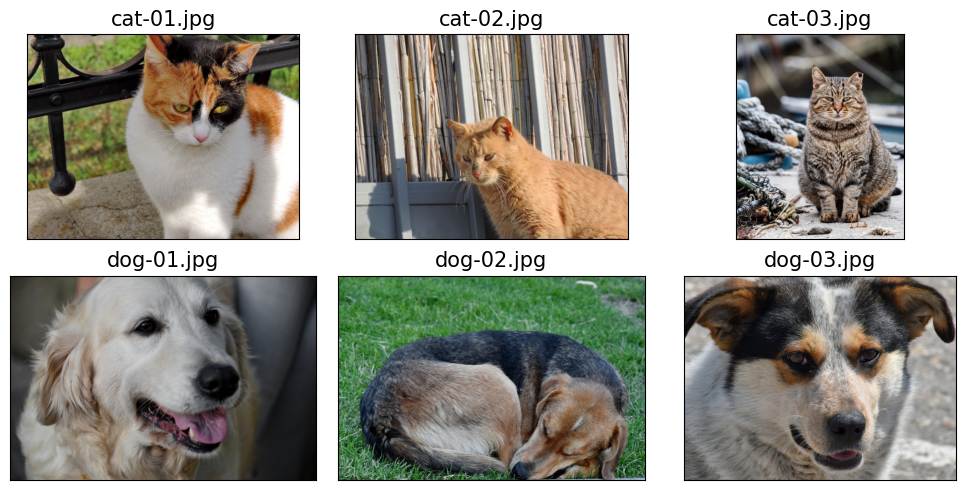

In [27]:
import matplotlib.pyplot as plt
import os
from PIL import Image
fig = plt.figure(figsize=(10, 5))
for i, file in enumerate(file_list):
    img = Image.open(file)
    print('Image shape:', np.array(img).shape)
    ax = fig.add_subplot(2, 3, i+1)
    ax.set_xticks([]); ax.set_yticks([])
    ax.imshow(img)
    ax.set_title(os.path.basename(file), size=15)
plt.tight_layout()
plt.show()

In [28]:
labels = [1 if 'dog' in os.path.basename(file) else 0 for file in file_list]
print(labels)

[0, 0, 0, 1, 1, 1]


In [29]:
class ImageDataset(Dataset):
    def __init__(self, file_list, labels):
        self.file_list = file_list
        self.labels = labels
    def __getitem__(self, index):
        file = self.file_list[index]
        label = self.labels[index]
        return file, label
    def __len__(self):
        return len(self.file_list)
    
image_dataset = ImageDataset(file_list, labels)
for file, label in image_dataset:
    print(file, label)

cat_dog_images\cat-01.jpg 0
cat_dog_images\cat-02.jpg 0
cat_dog_images\cat-03.jpg 0
cat_dog_images\dog-01.jpg 1
cat_dog_images\dog-02.jpg 1
cat_dog_images\dog-03.jpg 1


In [30]:
import torchvision.transforms as transforms
img_height, img_width = 80, 120
transform = transforms.Compose([ transforms.ToTensor(), 
                                transforms.Resize((img_height, img_width)),])

class ImageDataset(Dataset):
    def __init__(self, file_list, labels, transform=None):
        self.file_list = file_list
        self.labels = labels
        self.transform = transform
    def __getitem__(self, index):
        img = Image.open(self.file_list[index])
        if self.transform is not None:
            img = self.transform(img)
        label = self.labels[index]
        return img, label
    def __len__(self):
        return len(self.labels)

image_dataset = ImageDataset(file_list, labels, transform)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0005550324..1.0000002].


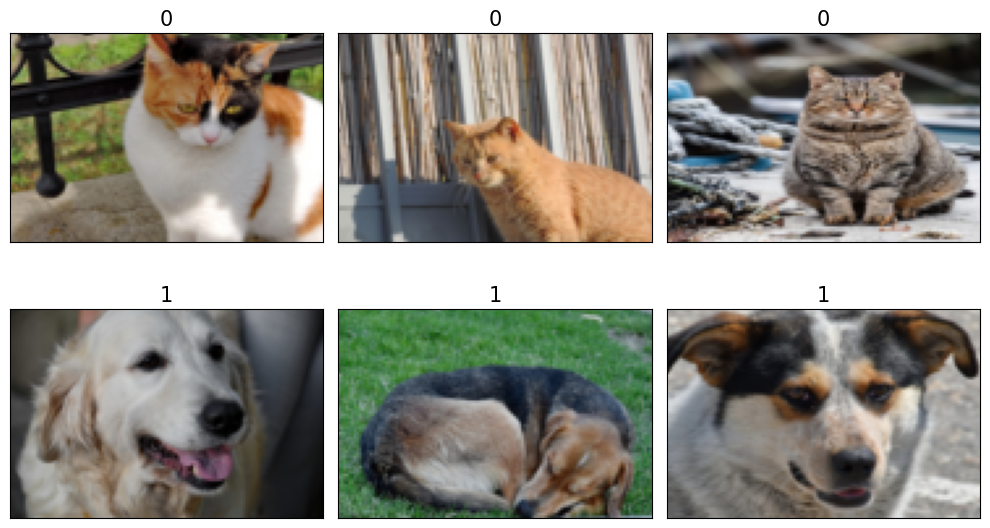

In [31]:
fig = plt.figure(figsize=(10, 6))
for i, example in enumerate(image_dataset):
    ax = fig.add_subplot(2, 3, i+1)
    ax.set_xticks([]); ax.set_yticks([])
    ax.imshow(example[0].numpy().transpose((1, 2, 0)))
    ax.set_title(f'{example[1]}', size=15)
plt.tight_layout()
plt.show()

### Fetching available datasets from the torchvision.datasets library

In [32]:
import torchvision 
image_path = 'C:/Users/Aksha/Desktop/Data Science Fundamentals/'
celeba_dataset = torchvision.datasets.CelebA(image_path, split='train', target_type='attr', download=False)
print('Train set:', len(celeba_dataset))

Train set: 162770


In [33]:
assert isinstance(celeba_dataset, torch.utils.data.Dataset)

In [34]:
example = next(iter(celeba_dataset))
print(example)

(<PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=178x218 at 0x19F0A8BE770>, tensor([0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0,
        1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1]))


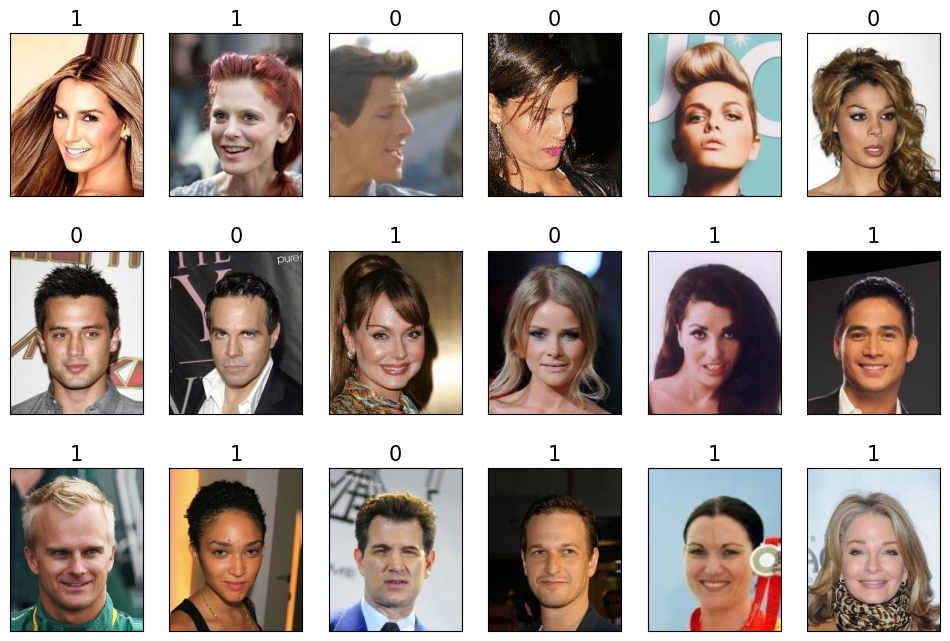

In [35]:
from itertools import islice
fig = plt.figure(figsize =(12,8))
for i, (image,attributes) in islice(enumerate(celeba_dataset),18):
    ax = fig.add_subplot(3,6,i+1)
    ax.set_xticks([]); ax.set_yticks([])
    ax.imshow(image)
    ax.set_title(f'{attributes[31]}', size = 15)
plt.show()


(<PIL.Image.Image image mode=L size=28x28 at 0x19F103752D0>, 5)


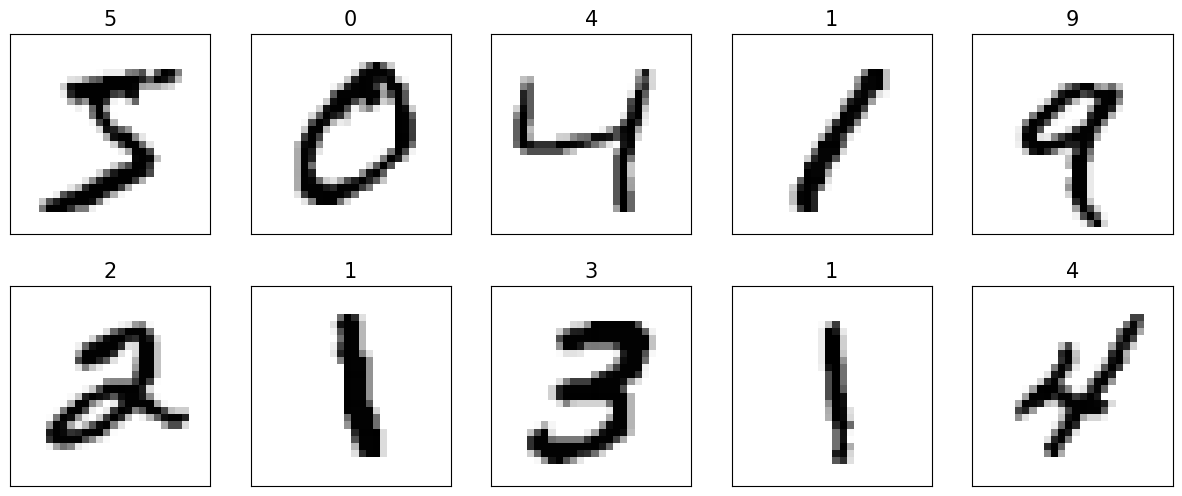

In [36]:
mnist_dataset = torchvision.datasets.MNIST(image_path, 'train', download=False)
assert isinstance(mnist_dataset, torch.utils.data.Dataset)
example = next(iter(mnist_dataset))
print(example)
fig = plt.figure(figsize=(15, 6))
for i, (image, label) in  islice(enumerate(mnist_dataset), 10):
    ax = fig.add_subplot(2, 5, i+1)
    ax.set_xticks([]); ax.set_yticks([])
    ax.imshow(image, cmap='gray_r')
    ax.set_title(f'{label}', size=15)
plt.show()

# building a linear regression model with pytorch

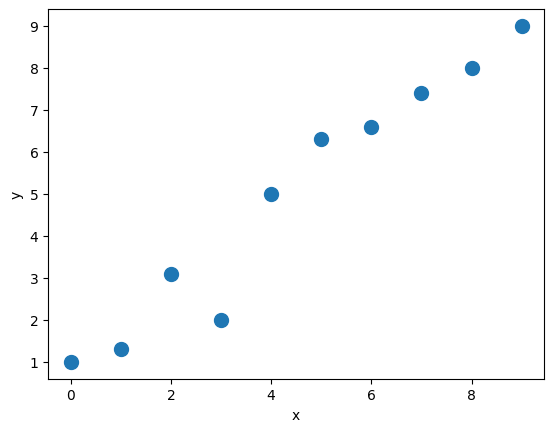

In [37]:
X_train = np.arange(10, dtype = 'float32').reshape((10,1))
y_train = np.array([1.0, 1.3, 3.1, 2.0, 5.0, 
                    6.3, 6.6,7.4, 8.0, 9.0], dtype='float32')
plt.plot(X_train, y_train, 'o', markersize=10)
plt.xlabel('x')
plt.ylabel('y')
plt.show()

In [38]:
from torch.utils.data import TensorDataset
X_train_norm = (X_train - np.mean(X_train)) / np.std(X_train)
X_train_norm = torch.from_numpy(X_train_norm)
y_train = torch.from_numpy(y_train)
train_ds = TensorDataset(X_train_norm, y_train)
batch_size = 1
train_dl = DataLoader(train_ds, batch_size, shuffle=True)

In [ ]:
torch.manual_seed(1)
weight = torch.randn(1)
weight.requires_grad_()
bias = torch.zeros(1, requires_grad=True)
def model(xb):
    return xb @ weight + bias

def loss_fn(input, target):
    return (input - target).pow(2).mean()

In [50]:
learning_rate = 0.001
num_epochs = 200
log_epochs = 10

for epoch in range(num_epochs):
    for x_batch, y_batch in train_dl:
        pred = model(x_batch)
        loss = loss_fn(pred, y_batch)
        loss.backward()

        with torch.no_grad():
            weight -= weight.grad * learning_rate
            bias -= bias.grad * learning_rate

        # Zero gradients for the next batch
        weight.grad.zero_()
        bias.grad.zero_()

    if epoch % log_epochs == 0:
        print(f'Epoch {epoch}  Loss {loss.item():.4f}')

# --- Final results ---
print(f"\nTrained weight: {weight.item():.4f}, bias: {bias.item():.4f}")

Epoch 0  Loss 0.0440
Epoch 10  Loss 0.2387
Epoch 20  Loss 0.0477
Epoch 30  Loss 0.2385
Epoch 40  Loss 0.0057
Epoch 50  Loss 0.0744
Epoch 60  Loss 0.7417
Epoch 70  Loss 0.0723
Epoch 80  Loss 0.0056
Epoch 90  Loss 0.0448
Epoch 100  Loss 0.0744
Epoch 110  Loss 0.2380
Epoch 120  Loss 0.0725
Epoch 130  Loss 0.7410
Epoch 140  Loss 0.0056
Epoch 150  Loss 0.0472
Epoch 160  Loss 0.7410
Epoch 170  Loss 0.0449
Epoch 180  Loss 0.0449
Epoch 190  Loss 2.4339

Trained weight: 2.7068, bias: 4.9696


Final Parameters: 2.706841230392456 4.969637393951416


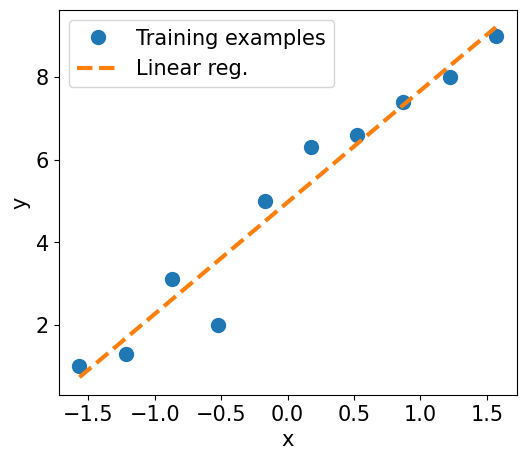

In [55]:
print('Final Parameters:', weight.item(), bias.item())
X_test = np.linspace(0, 9, num=100, dtype='float32').reshape(-1, 1)
X_test_norm = (X_test - np.mean(X_train)) / np.std(X_train)
X_test_norm = torch.from_numpy(X_test_norm)
y_pred = model(X_test_norm).detach().numpy()
fig = plt.figure(figsize=(13, 5))
ax = fig.add_subplot(1, 2, 1)
plt.plot(X_train_norm, y_train, 'o', markersize=10)
plt.plot(X_test_norm, y_pred, '--', lw=3)
plt.legend(['Training examples', 'Linear reg.'], fontsize=15)
ax.set_xlabel('x', size=15)
ax.set_ylabel('y', size=15)
ax.tick_params(axis='both', which='major', labelsize=15)
plt.show()


In [56]:
y_pred

array([0.729, 0.815, 0.9  , 0.986, 1.072, 1.157, 1.243, 1.329, 1.414,
       1.5  , 1.586, 1.671, 1.757, 1.843, 1.928, 2.014, 2.1  , 2.185,
       2.271, 2.357, 2.442, 2.528, 2.614, 2.699, 2.785, 2.871, 2.956,
       3.042, 3.128, 3.213, 3.299, 3.385, 3.47 , 3.556, 3.642, 3.727,
       3.813, 3.899, 3.984, 4.07 , 4.156, 4.241, 4.327, 4.413, 4.498,
       4.584, 4.67 , 4.755, 4.841, 4.927, 5.012, 5.098, 5.184, 5.269,
       5.355, 5.441, 5.527, 5.612, 5.698, 5.784, 5.869, 5.955, 6.041,
       6.126, 6.212, 6.298, 6.383, 6.469, 6.555, 6.64 , 6.726, 6.812,
       6.897, 6.983, 7.069, 7.154, 7.24 , 7.326, 7.411, 7.497, 7.583,
       7.668, 7.754, 7.84 , 7.925, 8.011, 8.097, 8.182, 8.268, 8.354,
       8.439, 8.525, 8.611, 8.696, 8.782, 8.868, 8.953, 9.039, 9.125,
       9.21 ], dtype=float32)

# Model training via the torch.nn and torch.optim modules

In [57]:
import torch.nn as nn
loss_fn = nn.MSELoss(reduction='mean')
input_size = 1
output_size = 1
model = nn.Linear(input_size, output_size)
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)


for epoch in range(num_epochs):
    for x_batch, y_batch in train_dl:
        # 1. Generate predictions
        pred = model(x_batch)[:, 0]
        # 2. Calculate loss
        loss = loss_fn(pred, y_batch)
        # 3. Compute gradients
        loss.backward()
        # 4. Update parameters using gradients
        optimizer.step()
        # 5. Reset the gradients to zero
        optimizer.zero_grad()    
    if epoch % log_epochs==0:
         print(f'Epoch {epoch}  Loss {loss.item():.4f}')

Epoch 0  Loss 48.0068
Epoch 10  Loss 4.8999
Epoch 20  Loss 9.4825
Epoch 30  Loss 15.1780
Epoch 40  Loss 10.4192
Epoch 50  Loss 7.4191
Epoch 60  Loss 4.9887
Epoch 70  Loss 0.1636
Epoch 80  Loss 2.4530
Epoch 90  Loss 1.7486
Epoch 100  Loss 0.3646
Epoch 110  Loss 0.3966
Epoch 120  Loss 1.9659
Epoch 130  Loss 0.5081
Epoch 140  Loss 0.0331
Epoch 150  Loss 0.1953
Epoch 160  Loss 0.0218
Epoch 170  Loss 1.1223
Epoch 180  Loss 0.0008
Epoch 190  Loss 0.1070


# Building a multilayer perceptron for classifying flowers in the  Iris dataset

In [62]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split 
iris = load_iris()
X = iris['data']
y = iris['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=1./3, random_state=1)

In [63]:
X_train_norm = (X_train - np.mean(X_train)) / np.std(X_train)
X_train_norm = torch.from_numpy(X_train_norm).float()
y_train = torch.from_numpy(y_train) 
train_ds = TensorDataset(X_train_norm, y_train)
torch.manual_seed(1)
batch_size = 2
train_dl = DataLoader(train_ds, batch_size, shuffle=True)

In [65]:
class Model(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()
        self.layer1 = nn.Linear(input_size, hidden_size)
        self.layer2 = nn.Linear(hidden_size, output_size)
    
    def forward(self, x):
        x = self.layer1(x)
        x = nn.Sigmoid()(x)
        x = self.layer2(x)
        x = nn.Softmax(dim=1)(x)
        return x 
    
input_size = X_train_norm.shape[1]
hidden_size = 16
output_size = 3 
model = Model(input_size, hidden_size, output_size)

In [68]:
learning_rate = 0.001
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)


num_epochs = 100
loss_hist = [0] * num_epochs
accuracy_hist = [0] * num_epochs
for epoch in range(num_epochs):
    for x_batch, y_batch in train_dl:
        pred = model(x_batch)
        loss = loss_fn(pred, y_batch)
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        loss_hist[epoch] += loss.item()*y_batch.size(0)
        is_correct = (torch.argmax(pred, dim=1) == y_batch).float()
        accuracy_hist[epoch] += is_correct.mean()
    loss_hist[epoch] /= len(train_dl.dataset)
    accuracy_hist[epoch] /= len(train_dl.dataset)

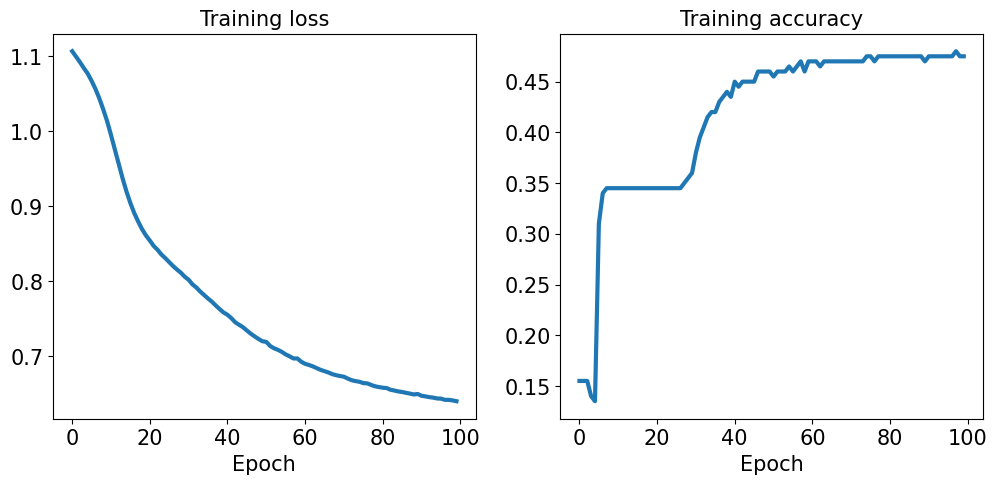

In [69]:
fig = plt.figure(figsize=(12, 5))
ax = fig.add_subplot(1, 2, 1)
ax.plot(loss_hist, lw=3)
ax.set_title('Training loss', size=15)
ax.set_xlabel('Epoch', size=15)
ax.tick_params(axis='both', which='major', labelsize=15)
ax = fig.add_subplot(1, 2, 2)
ax.plot(accuracy_hist, lw=3)
ax.set_title('Training accuracy', size=15)
ax.set_xlabel('Epoch', size=15)
ax.tick_params(axis='both', which='major', labelsize=15)
plt.show()

In [70]:
X_test_norm = (X_test - np.mean(X_train)) / np.std(X_train)
X_test_norm = torch.from_numpy(X_test_norm).float()
y_test = torch.from_numpy(y_test) 
pred_test = model(X_test_norm)
correct = (torch.argmax(pred_test, dim=1) == y_test).float()
accuracy = correct.mean()
print(f'Test Acc.: {accuracy:.4f}')


Test Acc.: 0.9800
